In [1]:
from google.colab import drive
import sys
drive.mount("/content/drive")
sys.path.append("/content/drive/MyDrive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from rich.traceback import install
install()

import gc
import json
from pathlib import Path

import cv2
import numpy as np
import torch
from skimage import io

from setup_helper import (
    DRIVE_BASE, INPUT_DIR, OUTPUT_DIR,
    download_repos_and_setup,
    show_image, plot_masks,
)
from alignment_helpers import (
    load_image,
    find_roi_with_origins,
    save_search_regions, load_search_regions,
    tile_flm,
    save_tiles, load_tiles_manifest,
    save_images_to_dir,
    filter_with_threshold,
    process_tem_image,
    generate_tem_masks,
    run_lightglue_matching, save_match_records,
    build_alignment_results,
    visualize_overlay,
    save_result_bundle,
    MatchRecord,
)

# ── Inputs ───────────────────────────────────────────────────────────────────
FLM_STACK_PATH = INPUT_DIR / "FLM-stack_JEY002_G3_L3.tif"
TEM_IMAGE_PATH = INPUT_DIR / "JEY002_G3_L3_1950x_t-13.tif"

flm_pixel_nm   = 121.0
tem_pixel_nm   = 6.9
expected_scale = flm_pixel_nm / tem_pixel_nm   # ~17.5

# ── Output tree ──────────────────────────────────────────────────────────────
FLM_FRAMES_DIR = OUTPUT_DIR / "flm_frames"
TEM_DIR        = OUTPUT_DIR / "tem"
MATCHES_DIR    = OUTPUT_DIR / "matches"
RESULTS_DIR    = OUTPUT_DIR / "results"

for d in [FLM_FRAMES_DIR, TEM_DIR, MATCHES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [9]:
from skimage.filters import threshold_otsu

flm_stack = io.imread(str(FLM_STACK_PATH))

otsu_values = {}
for frame_idx in range(flm_stack.shape[0]):
    green = flm_stack[frame_idx, :, :, 0].astype(float)
    blue  = flm_stack[frame_idx, :, :, 2].astype(float)
    ref  = flm_stack[frame_idx, :, :, 1].astype(float)
    bl_gr = ref
    otsu_values[frame_idx] = threshold_otsu(bl_gr)
    print(f"Frame {frame_idx}: Otsu threshold = {otsu_values[frame_idx]:.2f}")

sharpest_frame = max(otsu_values, key=otsu_values.get)
print(f"\nSharpest frame: {sharpest_frame} (threshold={otsu_values[sharpest_frame]:.2f})")

del flm_stack
gc.collect()

Frame 0: Otsu threshold = 750.46
Frame 1: Otsu threshold = 757.21
Frame 2: Otsu threshold = 760.84
Frame 3: Otsu threshold = 769.94
Frame 4: Otsu threshold = 777.71
Frame 5: Otsu threshold = 783.77
Frame 6: Otsu threshold = 781.43
Frame 7: Otsu threshold = 787.44
Frame 8: Otsu threshold = 786.41
Frame 9: Otsu threshold = 787.18
Frame 10: Otsu threshold = 777.51
Frame 11: Otsu threshold = 781.85
Frame 12: Otsu threshold = 781.95
Frame 13: Otsu threshold = 769.87
Frame 14: Otsu threshold = 765.95
Frame 15: Otsu threshold = 764.55
Frame 16: Otsu threshold = 770.32
Frame 17: Otsu threshold = 764.60
Frame 18: Otsu threshold = 766.32
Frame 19: Otsu threshold = 771.26
Frame 20: Otsu threshold = 765.96

Sharpest frame: 7 (threshold=787.44)


49

In [13]:
from skimage.filters import threshold_otsu

flm_stack = io.imread(str(FLM_STACK_PATH))
img_tem   = io.imread(str(TEM_IMAGE_PATH))

otsu_roi = {}
for frame_idx in range(flm_stack.shape[0]):
    flm_frame = flm_stack[frame_idx]
    crops, _ = find_roi_with_origins(flm_frame, img_tem, flm_pixel_nm, tem_pixel_nm, pad_factor=2)

    # compute Otsu on the reflection channel of each ROI crop and average
    values = []
    areas = []
    for crop in crops:
        if crop.max() == crop.min():
            continue
        values.append(threshold_otsu(crop))
        areas.append(crop.shape[0] * crop.shape[1])

    if values:
        otsu_roi[frame_idx] = np.average(values, weights=areas)
    else:
        otsu_roi[frame_idx] = 0

    # otsu_roi[frame_idx] = np.mean(values) if values else 0
    print(f"Frame {frame_idx}: ROI Otsu = {otsu_roi[frame_idx]:.2f}")

sharpest = max(otsu_roi, key=otsu_roi.get)
print(f"\nSharpest frame in ROI: {sharpest}")

del flm_stack, img_tem
gc.collect()

Frame 0: ROI Otsu = 865.61
Frame 1: ROI Otsu = 867.91
Frame 2: ROI Otsu = 871.18
Frame 3: ROI Otsu = 876.05
Frame 4: ROI Otsu = 881.77
Frame 5: ROI Otsu = 885.55
Frame 6: ROI Otsu = 890.64
Frame 7: ROI Otsu = 897.38
Frame 8: ROI Otsu = 903.16
Frame 9: ROI Otsu = 908.52
Frame 10: ROI Otsu = 904.63
Frame 11: ROI Otsu = 909.31
Frame 12: ROI Otsu = 903.50
Frame 13: ROI Otsu = 900.48
Frame 14: ROI Otsu = 898.88
Frame 15: ROI Otsu = 892.34
Frame 16: ROI Otsu = 889.24
Frame 17: ROI Otsu = 885.56
Frame 18: ROI Otsu = 880.42
Frame 19: ROI Otsu = 876.61
Frame 20: ROI Otsu = 868.77

Sharpest frame in ROI: 11


0

In [15]:
from skimage.filters import threshold_otsu

flm_stack = io.imread(str(FLM_STACK_PATH))
img_tem   = io.imread(str(TEM_IMAGE_PATH))

focus_scores = {}
for frame_idx in range(flm_stack.shape[0]):
    flm_frame = flm_stack[frame_idx]
    crops, _ = find_roi_with_origins(flm_frame, img_tem, flm_pixel_nm, tem_pixel_nm, pad_factor=2)

    values = []
    areas  = []
    for crop in crops:
        if crop.max() == crop.min():
            continue
        crop_u8 = ((crop - crop.min()) / (crop.max() - crop.min()) * 255).astype(np.uint8)
        lap = cv2.Laplacian(crop_u8, cv2.CV_64F).var()
        values.append(lap)
        areas.append(crop.shape[0] * crop.shape[1])

    focus_scores[frame_idx] = max(values) if values else 0
    # focus_scores[frame_idx] = np.average(values, weights=areas) if values else 0
    print(f"Frame {frame_idx}: Laplacian var = {focus_scores[frame_idx]:.4f}")

sharpest = max(focus_scores, key=focus_scores.get)
print(f"\nSharpest frame: {sharpest}")

del flm_stack, img_tem
gc.collect()

Frame 0: Laplacian var = 256.4311
Frame 1: Laplacian var = 242.3600
Frame 2: Laplacian var = 224.1848
Frame 3: Laplacian var = 199.0365
Frame 4: Laplacian var = 187.5306
Frame 5: Laplacian var = 175.1389
Frame 6: Laplacian var = 181.2187
Frame 7: Laplacian var = 181.3412
Frame 8: Laplacian var = 179.4408
Frame 9: Laplacian var = 164.9765
Frame 10: Laplacian var = 187.3720
Frame 11: Laplacian var = 206.6232
Frame 12: Laplacian var = 212.6465
Frame 13: Laplacian var = 203.6925
Frame 14: Laplacian var = 201.1346
Frame 15: Laplacian var = 169.6971
Frame 16: Laplacian var = 149.9560
Frame 17: Laplacian var = 130.4011
Frame 18: Laplacian var = 141.2913
Frame 19: Laplacian var = 147.8150
Frame 20: Laplacian var = 161.3801

Sharpest frame: 0


0

In [22]:
from shapely.geometry import box

flm_stack = io.imread(str(FLM_STACK_PATH))
img_tem   = io.imread(str(TEM_IMAGE_PATH))

# collect all ROIs across all frames with their bounding boxes and laplacian
all_rois = []  # list of {frame_idx, origin, bbox, laplacian}

for frame_idx in range(flm_stack.shape[0]):
    flm_frame = flm_stack[frame_idx]
    crops, origins = find_roi_with_origins(flm_frame, img_tem, flm_pixel_nm, tem_pixel_nm, pad_factor=1)

    for crop, (ox, oy) in zip(crops, origins):
        if crop.max() == crop.min():
            continue
        h, w = crop.shape[:2]
        crop_u8 = ((crop - crop.min()) / (crop.max() - crop.min()) * 255).astype(np.uint8)
        lap = cv2.Laplacian(crop_u8, cv2.CV_64F).var()
        mean_intensity = crop.mean()
        all_rois.append({
            "frame_idx": frame_idx,
            "origin":    (ox, oy),
            "bbox":      (ox, oy, ox + w, oy + h),  # (x0, y0, x1, y1)
            "laplacian": lap,
            "mean_intensity": 1,
            "area":      w * h,
        })

del flm_stack, img_tem
gc.collect()

# group by spatial overlap using IoU
def iou(b1, b2):
    ix0 = max(b1[0], b2[0])
    iy0 = max(b1[1], b2[1])
    ix1 = min(b1[2], b2[2])
    iy1 = min(b1[3], b2[3])
    if ix1 <= ix0 or iy1 <= iy0:
        return 0.0
    inter = (ix1 - ix0) * (iy1 - iy0)
    a1    = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2    = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter)

IOU_THRESHOLD = 0.3
groups = []  # list of lists of roi indices
assigned = [False] * len(all_rois)

import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(len(all_rois)))

for i in range(len(all_rois)):
    for j in range(i + 1, len(all_rois)):
        if iou(all_rois[i]["bbox"], all_rois[j]["bbox"]) >= IOU_THRESHOLD:
            G.add_edge(i, j)

groups = list(nx.connected_components(G))

best_per_group = []
for group in groups:
    best_idx = max(group, key=lambda i: all_rois[i]["laplacian"] * all_rois[i]["mean_intensity"])
    best_roi = all_rois[best_idx]
    best_per_group.append(best_roi)
    print(f"ROI group size={len(group):2d}  "
          f"best frame={best_roi['frame_idx']:2d}  "
          f"laplacian={best_roi['laplacian']:.2f}  "
          f"mean_intensity={best_roi['mean_intensity']:.2f}  "
          f"bbox={best_roi['bbox']}")

frames_to_process = sorted(set(r["frame_idx"] for r in best_per_group))
print(f"\nFrames to process: {frames_to_process}")

ROI group size=21  best frame= 6  laplacian=206.66  mean_intensity=1.00  bbox=(1506, 0, 2000, 351)
ROI group size=21  best frame=11  laplacian=119.05  mean_intensity=1.00  bbox=(825, 365, 1770, 1599)
ROI group size=21  best frame= 0  laplacian=314.85  mean_intensity=1.00  bbox=(1759, 1799, 2000, 2000)
ROI group size=19  best frame=10  laplacian=240.28  mean_intensity=1.00  bbox=(567, 1741, 897, 2000)

Frames to process: [0, 6, 10, 11]


In [20]:
for crop, (ox, oy) in zip(crops, origins):
    if crop.max() == crop.min():
        continue
    h, w = crop.shape[:2]
    crop_u8 = ((crop - crop.min()) / (crop.max() - crop.min()) * 255).astype(np.uint8)
    lap = cv2.Laplacian(crop_u8, cv2.CV_64F).var()
    mean_intensity = crop.mean()
    all_rois.append({
        ...
        "laplacian":       lap,
        "mean_intensity":  mean_intensity,
    })

╭──────────────────────────────────────────────────────────────────────────────────────────────────╮
│         ...                                                                                      │
│         ▲                                                                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
SyntaxError: invalid syntax. Perhaps you forgot a comma?

In [ ]:
download_repos_and_setup()

✓ All repos ready.


In [ ]:
#  Reads   : FLM stack + TEM image (sizing only)
#  Writes  : flm_frames/frame_XX/search_regions/{*.png, meta.json}
#  Memory  : one frame loaded, processed, saved, deleted before next frame

flm_stack = io.imread(str(FLM_STACK_PATH))
n_frames  = flm_stack.shape[0]
img_tem   = io.imread(str(TEM_IMAGE_PATH))
print(f"FLM stack: {flm_stack.shape}   TEM: {img_tem.shape}   frames: {n_frames}")

for frame_idx in range(n_frames):
    sr_dir = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}" / "search_regions"
    if (sr_dir / "meta.json").exists():
        print(f"Frame {frame_idx}: already done, skipping.")
        continue

    flm_frame = flm_stack[frame_idx]
    crops, origins = find_roi_with_origins(
        flm_frame, img_tem, flm_pixel_nm, tem_pixel_nm, pad_factor=2
    )
    save_search_regions(crops, origins, sr_dir)
    print(f"Frame {frame_idx}: {len(crops)} search region(s) saved.")

    del flm_frame, crops, origins
    gc.collect()

del flm_stack, img_tem
gc.collect()
print("Done – search regions.")

FLM stack: (21, 2000, 2000, 3)   TEM: (1366, 1366, 3)   frames: 21
Frame 0: already done, skipping.
Frame 1: already done, skipping.
Frame 2: already done, skipping.
Frame 3: already done, skipping.
Frame 4: already done, skipping.
Frame 5: already done, skipping.
Frame 6: already done, skipping.
Frame 7: already done, skipping.
Frame 8: already done, skipping.
Frame 9: already done, skipping.
Frame 10: already done, skipping.
Frame 11: already done, skipping.
Frame 12: already done, skipping.
Frame 13: already done, skipping.
Frame 14: already done, skipping.
Frame 15: already done, skipping.
Frame 16: already done, skipping.
Frame 17: already done, skipping.
Frame 18: already done, skipping.
Frame 19: already done, skipping.
Frame 20: already done, skipping.
Done – search regions.


In [ ]:
#  Reads   : search_regions/ from disk + TEM image (sizing only)
#  Writes  : flm_frames/frame_XX/tiles/{*.png, manifest.json}
#  Memory  : one frame at a time

img_tem  = io.imread(str(TEM_IMAGE_PATH))
n_frames = len(sorted(FLM_FRAMES_DIR.glob("frame_*")))

for frame_idx in range(n_frames):
    frame_dir = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    tiles_dir = frame_dir / "tiles"
    if (tiles_dir / "manifest.json").exists():
        print(f"Frame {frame_idx}: tiles already done, skipping.")
        continue

    crops, origins = load_search_regions(frame_dir / "search_regions")
    tiles_per_sr = [
        tile_flm(crop, img_tem, flm_pixel_nm=flm_pixel_nm,
                 tem_pixel_nm=tem_pixel_nm, tile_scale=2, use_hist_eq=True)
        for crop in crops
    ]
    save_tiles(tiles_per_sr, origins, tiles_dir)
    n_tiles = sum(len(t) for t in tiles_per_sr)
    print(f"Frame {frame_idx}: {n_tiles} tiles saved.")

    del crops, origins, tiles_per_sr
    gc.collect()

del img_tem
gc.collect()
print("Done – tiles.")

Frame 0: tiles already done, skipping.
Frame 1: tiles already done, skipping.
Frame 2: tiles already done, skipping.
Frame 3: tiles already done, skipping.
Frame 4: tiles already done, skipping.
Frame 5: tiles already done, skipping.
Frame 6: tiles already done, skipping.
Frame 7: tiles already done, skipping.
Frame 8: tiles already done, skipping.
Frame 9: tiles already done, skipping.
Frame 10: tiles already done, skipping.
Frame 11: tiles already done, skipping.
Frame 12: tiles already done, skipping.
Frame 13: tiles already done, skipping.
Frame 14: tiles already done, skipping.
Frame 15: tiles already done, skipping.
Frame 16: tiles already done, skipping.
Frame 17: tiles already done, skipping.
Frame 18: tiles already done, skipping.
Frame 19: tiles already done, skipping.
Frame 20: tiles already done, skipping.
Done – tiles.


In [ ]:
from setup_helper import load_swinir_model, swinir_upscale

swinir_model = load_swinir_model()
n_frames     = len(sorted(FLM_FRAMES_DIR.glob("frame_*")))

for frame_idx in range(n_frames):
    frame_dir = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    up_dir    = frame_dir / "tiles_upscaled"
    tile_images, manifest = load_tiles_manifest(frame_dir / "tiles")
    names = [m["file"] for m in manifest]

    if all((up_dir / n).exists() for n in names):
        print(f"Frame {frame_idx}: upscaled tiles already done, skipping.")
        del tile_images, manifest
        gc.collect()
        continue

    print(f"Frame {frame_idx}: upscaling {len(tile_images)} tiles …")
    upscaled = swinir_upscale(swinir_model, tile_images, window_size=8, max_batch_size=4)
    save_images_to_dir(upscaled, names, up_dir)
    print(f"Frame {frame_idx}: done.")

    del tile_images, upscaled
    torch.cuda.empty_cache()
    gc.collect()

del swinir_model
torch.cuda.empty_cache()
gc.collect()
print("Done – upscaling.")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ SwinIR loaded from 002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth
Frame 0: upscaled tiles already done, skipping.
Frame 1: upscaled tiles already done, skipping.
Frame 2: upscaled tiles already done, skipping.
Frame 3: upscaled tiles already done, skipping.
Frame 4: upscaled tiles already done, skipping.
Frame 5: upscaled tiles already done, skipping.
Frame 6: upscaled tiles already done, skipping.
Frame 7: upscaled tiles already done, skipping.
Frame 8: upscaled tiles already done, skipping.
Frame 9: upscaled tiles already done, skipping.
Frame 10: upscaled tiles already done, skipping.
Frame 11: upscaled tiles already done, skipping.
Frame 12: upscaled tiles already done, skipping.
Frame 13: upscaled tiles already done, skipping.
Frame 14: upscaled tiles already done, skipping.
Frame 15: upscaled tiles already done, skipping.
Frame 16: upscaled tiles already done, skipping.
Frame 17: upscaled tiles already done, skipping.
Frame 18: upscaled tiles already done, skipping.
Frame 19: up

In [ ]:
#  Reads   : tiles_upscaled/ from disk
#  Writes  : tiles_filtered/
#  Memory  : one image at a time, no model

n_frames = len(sorted(FLM_FRAMES_DIR.glob("frame_*")))

for frame_idx in range(n_frames):
    frame_dir = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    up_dir    = frame_dir / "tiles_upscaled"
    filt_dir  = frame_dir / "tiles_filtered"
    _, manifest = load_tiles_manifest(frame_dir / "tiles")
    names = [m["file"] for m in manifest]

    if all((filt_dir / n).exists() for n in names):
        print(f"Frame {frame_idx}: filtered tiles already done, skipping.")
        continue

    filt_dir.mkdir(parents=True, exist_ok=True)
    print(f"Frame {frame_idx}: filtering {len(names)} tiles …")
    for name in names:
        img = cv2.imread(str(up_dir / name))
        if img is None:
            continue
        gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        filtered = filter_with_threshold(gray, threshold=130)
        cv2.imwrite(str(filt_dir / name), filtered)
        del img, gray, filtered

    gc.collect()
    print(f"Frame {frame_idx}: done.")

print("Done – filtering.")

Frame 0: filtered tiles already done, skipping.
Frame 1: filtered tiles already done, skipping.
Frame 2: filtered tiles already done, skipping.
Frame 3: filtered tiles already done, skipping.
Frame 4: filtered tiles already done, skipping.
Frame 5: filtered tiles already done, skipping.
Frame 6: filtered tiles already done, skipping.
Frame 7: filtered tiles already done, skipping.
Frame 8: filtered tiles already done, skipping.
Frame 9: filtered tiles already done, skipping.
Frame 10: filtered tiles already done, skipping.
Frame 11: filtered tiles already done, skipping.
Frame 12: filtered tiles already done, skipping.
Frame 13: filtered tiles already done, skipping.
Frame 14: filtered tiles already done, skipping.
Frame 15: filtered tiles already done, skipping.
Frame 16: filtered tiles already done, skipping.
Frame 17: filtered tiles already done, skipping.
Frame 18: filtered tiles already done, skipping.
Frame 19: filtered tiles already done, skipping.
Frame 20: filtered tiles alrea

TEM filtered image already on disk.


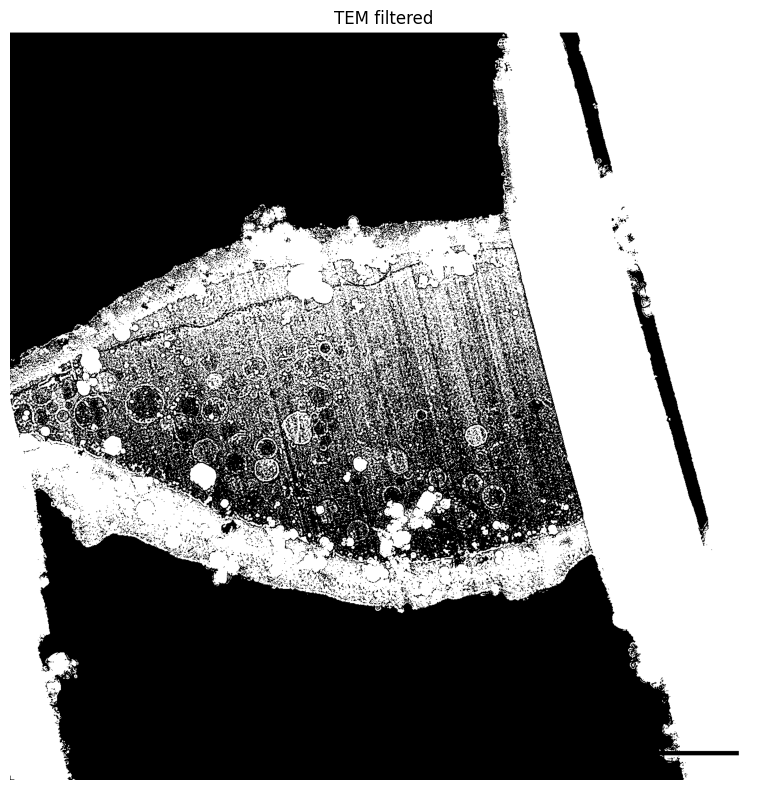

✓ SAM loaded.
  Generated 10 TEM masks → /content/drive/MyDrive/output/tem/masks


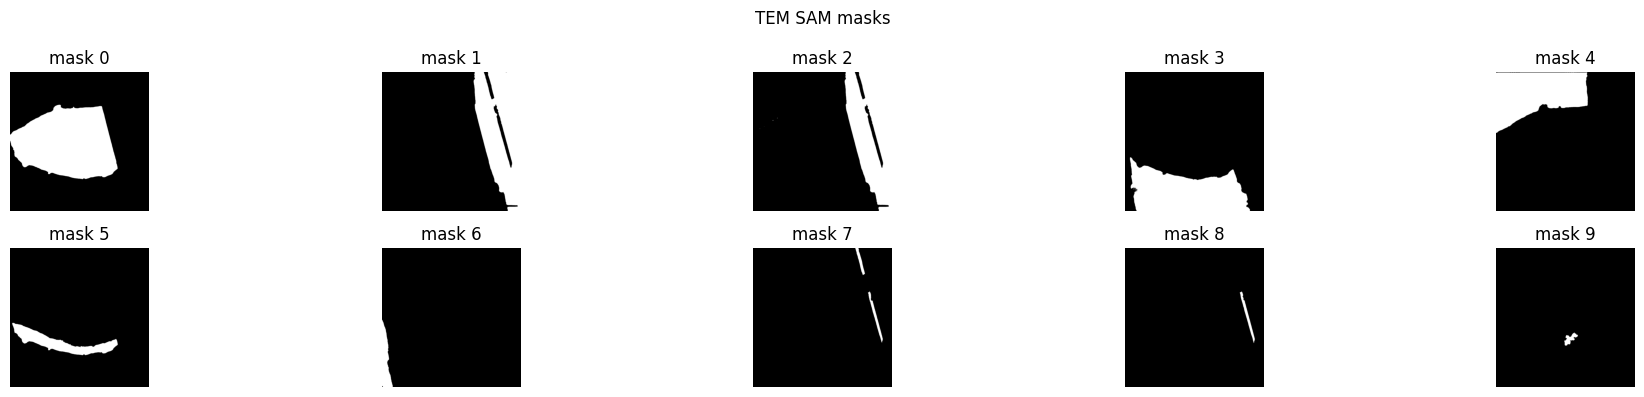

Done – TEM processing.


In [15]:
#  Reads   : TEM image
#  Writes  : tem/processing/  and  tem/masks/
#  Memory  : SAM model loaded, masks generated, model deleted

from setup_helper import load_sam_model

TEM_PROC_DIR  = TEM_DIR / "processing"
TEM_MASKS_DIR = TEM_DIR / "masks"

if not (TEM_PROC_DIR / "tem_filtered.png").exists():
    process_tem_image(TEM_IMAGE_PATH, threshold=130, out_dir=TEM_PROC_DIR)
else:
    print("TEM filtered image already on disk.")

tem_filtered = cv2.imread(str(TEM_PROC_DIR / "tem_filtered.png"), cv2.IMREAD_GRAYSCALE)
tem_gray_u8  = cv2.imread(str(TEM_PROC_DIR / "tem_gray.png"),     cv2.IMREAD_GRAYSCALE)
show_image(tem_filtered, title="TEM filtered")


if len(list(TEM_MASKS_DIR.glob("mask_*.png"))) == 0:
    sam_model, mask_generator = load_sam_model()
    generate_tem_masks(mask_generator, tem_filtered, TEM_MASKS_DIR, top_k=10)
    del sam_model, mask_generator
    torch.cuda.empty_cache()
    gc.collect()
else:
    print("TEM masks already on disk.")

del tem_gray_u8
gc.collect()

# quick visual check
tem_masks_preview = [
    cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    for p in sorted(TEM_MASKS_DIR.glob("mask_*.png"))
]
plot_masks(tem_masks_preview, ncols=5, title="TEM SAM masks")
del tem_masks_preview
gc.collect()
print("Done – TEM processing.")

In [ ]:
#  Reads   : tiles_filtered/ + tem/masks/ from disk
#  Writes  : matches/frame_XX/{match_*.npz, match_meta.json}
#  Memory  : LightGlue loaded once; filtered tiles for one frame at a time;
#            both deleted at end of cell

from setup_helper import load_lightglue_models

extractor, matcher = load_lightglue_models(filter_threshold=0.05)
n_frames = len(sorted(FLM_FRAMES_DIR.glob("frame_*")))

tem_masks = [
    cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    for p in sorted(TEM_MASKS_DIR.glob("mask_*.png"))
]

for frame_idx in range(n_frames):
    match_dir = MATCHES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    if (match_dir / "match_meta.json").exists():
        print(f"Frame {frame_idx}: matches already done, skipping.")
        continue

    frame_dir = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    filt_dir  = frame_dir / "tiles_filtered"
    _, manifest = load_tiles_manifest(frame_dir / "tiles")

    filtered_tiles = [
        cv2.imread(str(filt_dir / m["file"]), cv2.IMREAD_GRAYSCALE)
        for m in manifest
    ]

    print(f"Frame {frame_idx}: matching {len(filtered_tiles)} tiles × {len(tem_masks)} masks …")
    records = run_lightglue_matching(
        extractor, matcher,
        filtered_tiles=filtered_tiles,
        tile_manifest=manifest,
        tem_masks=tem_masks,
        frame_idx=frame_idx,
        device=device,
    )
    save_match_records(records, match_dir)
    print(f"Frame {frame_idx}: {len(records)} pairs saved.")

    del filtered_tiles, records
    torch.cuda.empty_cache()
    gc.collect()

del extractor, matcher, tem_masks
torch.cuda.empty_cache()
gc.collect()
print("Done – matching.")

✓ SuperPoint + LightGlue loaded.
Frame 0: matching 222 tiles × 10 masks …
  Frame 0: 1208 tile-mask pairs with ≥1 match
Frame 0: 1208 pairs saved.
Frame 1: matching 234 tiles × 10 masks …
  Frame 1: 1255 tile-mask pairs with ≥1 match
Frame 1: 1255 pairs saved.
Frame 2: matching 249 tiles × 10 masks …
  Frame 2: 1337 tile-mask pairs with ≥1 match
Frame 2: 1337 pairs saved.
Frame 3: matching 266 tiles × 10 masks …
  Frame 3: 1437 tile-mask pairs with ≥1 match
Frame 3: 1437 pairs saved.
Frame 4: matching 266 tiles × 10 masks …
  Frame 4: 1417 tile-mask pairs with ≥1 match
Frame 4: 1417 pairs saved.
Frame 5: matching 266 tiles × 10 masks …
  Frame 5: 1433 tile-mask pairs with ≥1 match
Frame 5: 1433 pairs saved.
Frame 6: matching 266 tiles × 10 masks …
  Frame 6: 1462 tile-mask pairs with ≥1 match
Frame 6: 1462 pairs saved.
Frame 7: matching 266 tiles × 10 masks …
  Frame 7: 1430 tile-mask pairs with ≥1 match
Frame 7: 1430 pairs saved.
Frame 8: matching 266 tiles × 10 masks …
  Frame 8: 138

In [ ]:
# Reads   : matches/frame_XX/ from disk  (just small numpy arrays)
# Writes  : nothing — results are small enough to keep for the next cell
# Memory  : keypoint arrays only, no images, no models

all_records = []
n_frames = len(sorted(MATCHES_DIR.glob("frame_*")))

for frame_idx in range(n_frames):
    match_dir = MATCHES_DIR / f"frame_{str(frame_idx).zfill(2)}"
    if not (match_dir / "match_meta.json").exists():
        print(f"Frame {frame_idx}: no match data, skipping.")
        continue

    with open(match_dir / "match_meta.json") as f:
        stored_meta = json.load(f)

    for i, m in enumerate(stored_meta):
        npz = np.load(str(match_dir / f"match_{str(i).zfill(4)}.npz"))
        all_records.append(MatchRecord(
            frame_idx     = m["frame_idx"],
            sr_idx        = m["sr_idx"],
            sr_origin_x   = m["sr_origin_x"],
            sr_origin_y   = m["sr_origin_y"],
            tile_origin_x = m["tile_origin_x"],
            tile_origin_y = m["tile_origin_y"],
            tem_mask_idx  = m["tem_mask_idx"],
            m_kpts_tem    = npz["m_kpts_tem"],
            m_kpts_tile   = npz["m_kpts_tile"],
            scores        = npz["scores"],
            n_matches     = m["n_matches"],
        ))

top_per_frame, best_per_frame = build_alignment_results(
    all_records, expected_scale=expected_scale, upscale_factor=4, top_n_per_frame=10
)
del all_records
gc.collect()

for frame_idx, frame_results in top_per_frame.items():
    print(f"Frame {frame_idx}: {len(frame_results)} candidates, "
          f"best n_matches={frame_results[0].match_record.n_matches}")

best = best_per_frame[0] if best_per_frame else None
if best:
    print(f"\nBest → frame={best.frame_idx}  scale={best.scale:.5f}  "
          f"(expected {expected_scale:.5f})")
else:
    print("No valid alignment found across any frame.")

Frame 0: 10 candidates, best n_matches=57
Frame 1: 10 candidates, best n_matches=68
Frame 2: 10 candidates, best n_matches=47
Frame 3: 10 candidates, best n_matches=65
Frame 4: 10 candidates, best n_matches=46
Frame 5: 10 candidates, best n_matches=65
Frame 6: 10 candidates, best n_matches=61
Frame 7: 10 candidates, best n_matches=54
Frame 8: 10 candidates, best n_matches=60
Frame 9: 10 candidates, best n_matches=50
Frame 10: 10 candidates, best n_matches=62
Frame 11: 10 candidates, best n_matches=44
Frame 12: 10 candidates, best n_matches=53
Frame 13: 10 candidates, best n_matches=45
Frame 14: 10 candidates, best n_matches=56
Frame 15: 10 candidates, best n_matches=55
Frame 16: 10 candidates, best n_matches=55
Frame 17: 10 candidates, best n_matches=46
Frame 18: 10 candidates, best n_matches=46
Frame 19: 10 candidates, best n_matches=56
Frame 20: 10 candidates, best n_matches=48

Best → frame=2  scale=17.64197  (expected 17.53623)


In [ ]:
# Reads   : FLM stack + TEM image
# Shows   : overlay for each frame's best result
# Memory  : one frame at a time

img_tem  = io.imread(str(TEM_IMAGE_PATH))
tem_gray = img_tem[:, :, 0] if img_tem.ndim == 3 else img_tem
tem_u8   = ((tem_gray.astype(float) / (tem_gray.max() + 1e-8)) * 255).astype(np.uint8)
del img_tem, tem_gray
gc.collect()

flm_stack = io.imread(str(FLM_STACK_PATH))

for result in best_per_frame:
    frame_refl = flm_stack[result.frame_idx, :, :, 1]
    frame_u8   = ((frame_refl.astype(float) / (frame_refl.max() + 1e-8)) * 255).astype(np.uint8)

    visualize_overlay(
        frame_u8, tem_u8, result.transform_M,
        title=f"Frame {result.frame_idx} | n_matches={result.match_record.n_matches} | scale={result.scale:.4f}",
    )

    del frame_refl, frame_u8
    gc.collect()

del flm_stack, tem_u8
gc.collect()

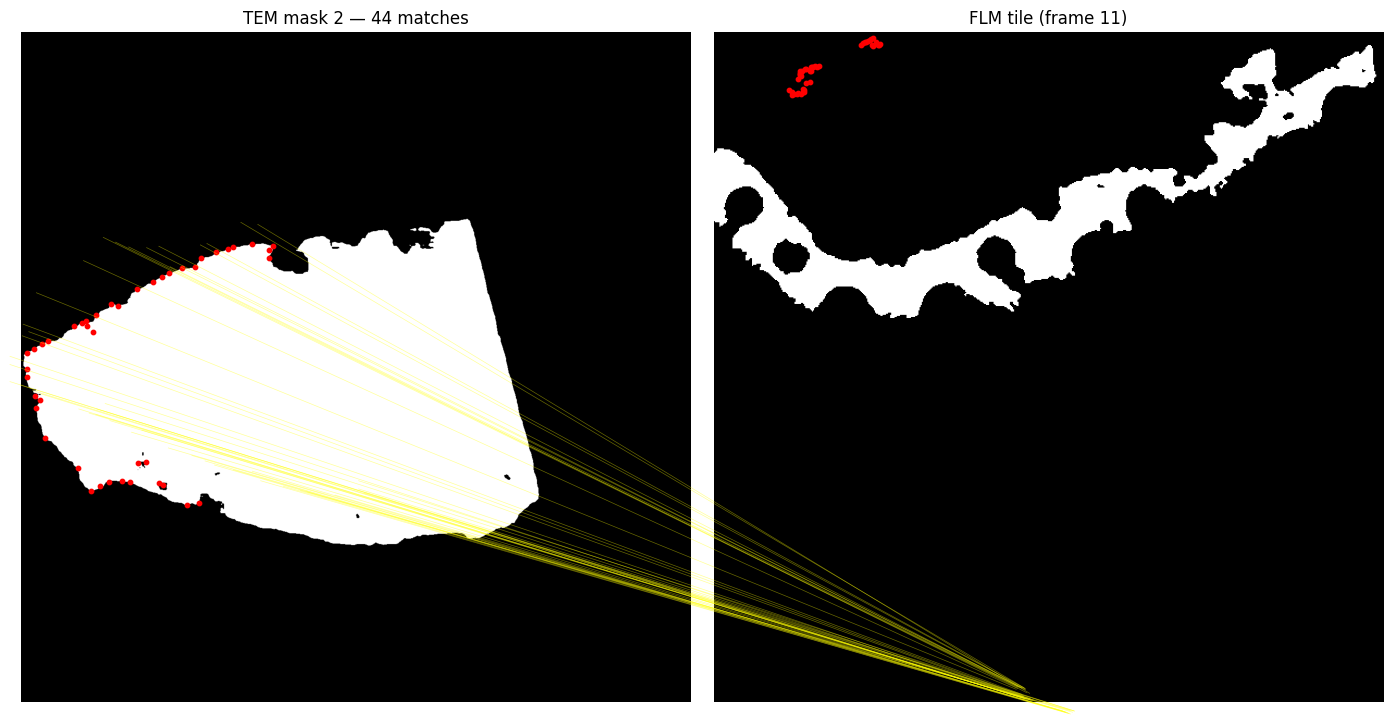

In [ ]:
import matplotlib.pyplot as plt

frame_idx = 11
result = top_per_frame[frame_idx][0]  # best by n_matches for frame 11

# load the specific tile and tem mask that produced this match
filt_dir  = FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}" / "tiles_filtered"
_, manifest = load_tiles_manifest(FLM_FRAMES_DIR / f"frame_{str(frame_idx).zfill(2)}" / "tiles")

# find the tile file from the manifest using sr_idx and tile origins
tile_meta = next(
    m for m in manifest
    if m["sr_idx"] == result.match_record.sr_idx
    and m["tile_origin_x"] == result.match_record.tile_origin_x
    and m["tile_origin_y"] == result.match_record.tile_origin_y
)
tile_img = cv2.imread(str(filt_dir / tile_meta["file"]), cv2.IMREAD_GRAYSCALE)
tem_mask = cv2.imread(str(TEM_MASKS_DIR / f"mask_{str(result.match_record.tem_mask_idx).zfill(2)}.png"), cv2.IMREAD_GRAYSCALE)

# matched keypoints in tile space (not back-projected, just for display)
kpts_tile = result.match_record.m_kpts_tile  # (N, 2) in upscaled tile space
kpts_tem  = result.match_record.m_kpts_tem   # (N, 2) in tem space

# scale tile keypoints back down for display on the filtered tile
kpts_tile_display = kpts_tile / 4.0  # undo swinir upscale

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(tem_mask, cmap="gray")
axes[0].scatter(kpts_tem[:, 0], kpts_tem[:, 1], c="red", s=10)
axes[0].set_title(f"TEM mask {result.match_record.tem_mask_idx} — {result.match_record.n_matches} matches")
axes[0].axis("off")

axes[1].imshow(tile_img, cmap="gray")
axes[1].scatter(kpts_tile_display[:, 0], kpts_tile_display[:, 1], c="red", s=10)
axes[1].set_title(f"FLM tile (frame {frame_idx})")
axes[1].axis("off")

# draw correspondence lines between the two images side by side
for i in range(len(kpts_tem)):
    # x in right image is offset by tem_mask width
    x0, y0 = kpts_tem[i]
    x1, y1 = kpts_tile_display[i, 0] + tem_mask.shape[1], kpts_tile_display[i, 1]
    fig.add_artist(plt.Line2D(
        [x0 / (tem_mask.shape[1] + tile_img.shape[1]),
         (x1) / (tem_mask.shape[1] + tile_img.shape[1])],
        [y0 / max(tem_mask.shape[0], tile_img.shape[0]),
         y1 / max(tem_mask.shape[0], tile_img.shape[0])],
        transform=fig.transFigure, color="yellow", alpha=0.4, linewidth=0.5
    ))

plt.tight_layout()
plt.show()